In [6]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm
from pathlib import Path

import sys
module_path = "../bin"
sys.path.insert(0, module_path)

import um_utils_plotting as umplt
import um_utils as um
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

um.WarningSuppress()

MEANS_DIR = Path("../Data/Models/Monthly_Means")
PROXY_DIR = Path("/Users/ajw1g19/Library/CloudStorage/OneDrive-UniversityofSouthampton/INSPIRE DTP/Projects/Palaeo-Proxies/")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
#------------------------------------------------------------
# PNAS Figure Specification
#------------------------------------------------------------

PNAS_WIDTH = {1: 3.42, 1.5: 4.5, 2: 7.0}      # inches
PNAS_MAX_HEIGHT = 9.0

def pnas_figsize(cols, height):
    """Figure size in inches for a PNAS column count and chosen height."""
    if height > PNAS_MAX_HEIGHT:
        raise ValueError(f"height {height}in exceeds PNAS maximum of {PNAS_MAX_HEIGHT}in")
    return (PNAS_WIDTH[cols], height)

FS = {              # font sizes
    "panel": 8,     # (a), (b) ... panel letters
    "title": 8,     # panel titles
    "label": 7,     # axis and colorbar labels
    "tick": 6,      # tick labels
    "legend": 6,    # legend
    "annot": 6,     # Axes annotations
}

LW = {              # line widths 
    "spine": 0.8,   # axes spines
    "coast": 0.5,   # map coastlines
    "border": 0.3,  # map borders 
    "grid": 0.2,    # gridlines
    "contour": 0.1, # contours
    "data": 0.8,    # scatter point edgewidths
}

MS = {              # marker sizes
    "proxy": 10,    # scatter points
    "legend": 4,    # legend markers
}

plt.rcParams.update(plt.rcParamsDefault)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [7]:
#------------------------------------------------------------
# Import UKESM Simulated Climate
#------------------------------------------------------------

MH_means = um.importUMData(MEANS_DIR / "MH_monthly_means.nc")
PI_means = um.importUMData(MEANS_DIR / "PI_monthly_means.nc")

ukesm_pr = (MH_means["pr"] - PI_means["pr"]) * 12 # Convert to mm/yr
ukesm_tas = MH_means["tas"] - PI_means["tas"]

#------------------------------------------------------------
# Import Bartlein Pollen Reconstructions
#------------------------------------------------------------

BART_MAT = um.importUMData(PROXY_DIR / "Bartlein" / "mat_delta_06ka_ALL_grid_2x2_ex.nc") 
BART_MAP = um.importUMData(PROXY_DIR / "Bartlein" / "map_delta_06ka_ALL_grid_2x2_ex.nc")

bart_mat = BART_MAT["mat_anm_mean"].stack(points=("lat", "lon")).dropna("points")
bart_map = BART_MAP["map_anm_mean"].stack(points=("lat", "lon")).dropna("points")

#------------------------------------------------------------
# Import Legacy Climate Reconstructions
#------------------------------------------------------------

LC_anoms_df = pd.read_excel(f"../Data/Proxies/LC_climate_reconstruction_anomalies.xlsx")
LC_anoms_df = LC_anoms_df[LC_anoms_df["Continent"].isin(["Western North America", "Eastern North America"])]

LC_lat = LC_anoms_df["Latitude"].values
LC_lon = LC_anoms_df["Longitude"].values

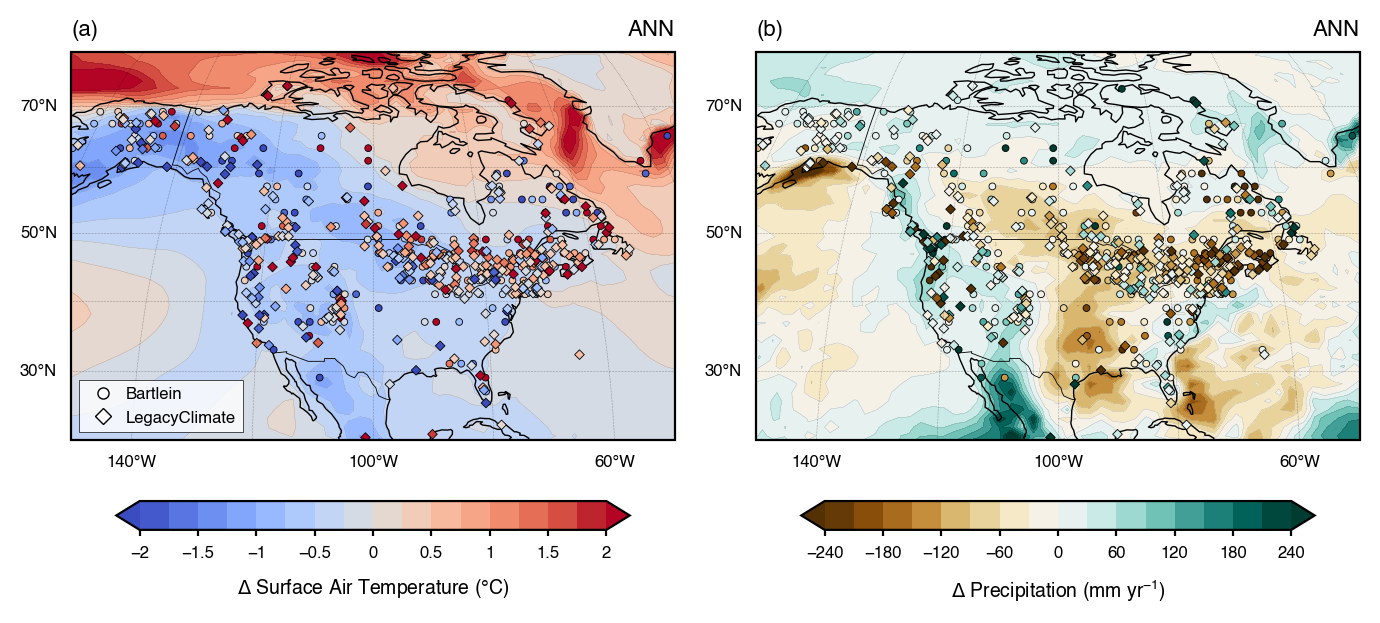

In [ ]:
#------------------------------------------------------------
# Colorbar Helper
#------------------------------------------------------------

def cbar_axes_under(fig, axes, width=0.9, height=0.018, pad=0.05):
    fig.canvas.draw()
    boxes = [ax.get_position(original=False) for ax in axes]

    x0 = min(b.x0 for b in boxes)
    x1 = max(b.x1 for b in boxes)
    y0 = min(b.y0 for b in boxes)

    w = (x1 - x0) * width
    return fig.add_axes([0.5 * (x0 + x1) - w / 2, y0 - pad, w, height])

#------------------------------------------------------------
# Properties for Maps
#------------------------------------------------------------

fig = plt.figure(figsize=pnas_figsize(2, 3.2), dpi=200)
gs = GridSpec(1, 2)

lims, proj = [-150, -50, 20, 80], ccrs.Robinson(central_longitude=-100)
LON, LAT = np.meshgrid(MH_means.longitude, MH_means.latitude)

RASTER_Z = 10

map_configs = [
    {
        "data": ukesm_tas,
        "cmap": cm.coolwarm,
        "levs": np.linspace(-2, 2, 17),
        "cbar_label": r"$\Delta$ Surface Air Temperature (°C)",
        "bart": bart_mat,
        "LC": LC_anoms_df["T air (annual mean) [°C] (MAT)"].values,
        "label": "a",
        "add_legend": True,
    },
    {
        "data": ukesm_pr,
        "cmap": cm.BrBG,
        "levs": np.linspace(-240, 240, 17),
        "cbar_label": r"$\Delta$ Precipitation (mm $\mathregular{yr^{-1}}$)",
        "bart": bart_map,
        "LC": LC_anoms_df["Precip annual total [mm/a] (MAT)"].values,
        "label": "b",
        "add_legend": False,
    },
]

#------------------------------------------------------------
# Plotting Maps
#------------------------------------------------------------

map_axes, mappables = [], []

for j, cfg in enumerate(map_configs):
    levs = cfg["levs"]
    norm = BoundaryNorm(levs, cfg["cmap"].N, extend="both")
    ann = cfg["data"].mean(dim="time")

    ax = plt.subplot(gs[0, j], projection=proj)
    ax.set_rasterization_zorder(RASTER_Z)

    umplt.plotBaseMap(ax, lims, bordercol="black",
                      coastlw=LW["coast"], borderlw=LW["border"], spinelw=LW["spine"])
    gl, glines = umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70],
                                xlines=[-40, -80, -120, -160], ylines=[40, 60],
                                labelsize=FS["tick"], lw=LW["grid"], ls="dotted", alph=0.6)
    gl.set_zorder(RASTER_Z + 1)
    glines.set_zorder(RASTER_Z - 1)

    cf = ax.contourf(LON, LAT, ann, extend="both", levels=levs, cmap=cfg["cmap"],
                     transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
    cs = ax.contour(LON, LAT, ann, levels=levs, colors="black", linestyles="dashed",
                    linewidths=LW["contour"] * 0.5, transform=ccrs.PlateCarree(),
                    transform_first=True, zorder=1)

    # Proxy reconstructions on top
    bart = cfg["bart"]
    ax.scatter(bart.lon, bart.lat, c=bart.values, s=MS["proxy"] * 0.6, marker="o", cmap=cfg["cmap"],
               norm=norm, edgecolors="black", linewidths=LW["border"],
               transform=ccrs.PlateCarree(), zorder=5)
    ax.scatter(LC_lon, LC_lat, c=cfg["LC"], s=MS["proxy"] * 0.6, marker="D", cmap=cfg["cmap"],
               norm=norm, edgecolors="black", linewidths=LW["border"],
               transform=ccrs.PlateCarree(), zorder=5)

    ax.set_title(f"({cfg['label']})", loc="left", fontsize=FS["panel"], pad=6, zorder=RASTER_Z + 1)
    ax.set_title("ANN", loc="right", fontsize=FS["title"], pad=6, zorder=RASTER_Z + 1)
    ax.spines["geo"].set_zorder(RASTER_Z + 1)

    if cfg["add_legend"]:
        point1 = Line2D([0], [0], marker="o", ms=MS["legend"], mec="k", mew=0.5, mfc="white", ls="")
        point2 = Line2D([0], [0], marker="D", ms=MS["legend"], mec="k", mew=0.5, mfc="white", ls="")
        lgd = ax.legend([point1, point2], ["Bartlein", "LegacyClimate"],
                        loc="lower left", fancybox=False, edgecolor="k",
                        fontsize=FS["legend"], handletextpad=0.4, borderpad=0.4)
        lgd.get_frame().set_linewidth(LW["border"])
        lgd.set_zorder(RASTER_Z + 1)

    map_axes.append(ax)
    mappables.append(cf)

#------------------------------------------------------------
# Colorbars and Final Adjustments
#------------------------------------------------------------

plt.tight_layout()

for cfg, ax, mappable in zip(map_configs, map_axes, mappables):
    cax = cbar_axes_under(fig, [ax], width=0.85, height=0.045, pad=0.14)
    cbar = fig.colorbar(mappable, cax=cax, orientation="horizontal", ticks=cfg["levs"][::2],
                        format=mticker.StrMethodFormatter("{x:g}"))
    cbar.ax.tick_params(labelsize=FS["tick"], length=2)
    cbar.set_label(cfg["cbar_label"], size=FS["label"], labelpad=6)

plt.show()
